In [21]:
import sys
import asyncio

if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

In [22]:
import threading
import queue

import supervision as sv
import io
from PIL import Image
from time import sleep
from playwright.sync_api import sync_playwright
import time


Set up the live feed

In [23]:
playwright_thread = None
playwright_url = "https://www.youtube.com/embed/2juLrCH5w9U?autoplay=1&mute=1"

class PlaywrightThread(threading.Thread):
    def __init__(self, url):
        super().__init__(daemon = True)
        self.url = url
        self.input = queue.Queue()
        self.output = queue.Queue()

    def run(self):
        with sync_playwright() as p:
            browser = p.firefox.launch(headless = True)
            context = browser.new_context(extra_http_headers = {"referer": "https://example.com/"})
            page = context.new_page()
            page.goto(self.url)
            while True:
                if not self.input.empty():
                    command = self.input.get()
                    if command == "screenshot":
                        screenshot_bytes = page.screenshot()
                        self.output.put(screenshot_bytes)
                    elif command == "exit":
                        break

            browser.close()
    
def setup():
    global playwright_thread
    if playwright_thread is None:
        playwright_thread = PlaywrightThread(playwright_url)
        playwright_thread.start()

def prt_sc():
    global playwright_thread
    
    playwright_thread.input.put("screenshot")
    image = playwright_thread.output.get()
    return Image.open(io.BytesIO(image))

def close():
    global playwright_thread
    if playwright_thread is not None:
        playwright_thread.input.put("exit")
        playwright_thread.join()
        playwright_thread = None

    


Set up the model

In [24]:
from transformers import AutoModelForMultimodalLM, AutoProcessor
import torch

torch.cuda.empty_cache()
try:
  del(model)
except:
  print()

model = AutoModelForMultimodalLM.from_pretrained(
    "google/gemma-4-E2B-it",
    dtype = "auto",
    device_map = "cuda"
    )
processor = AutoProcessor.from_pretrained("google/gemma-4-E2B-it")

Loading weights: 100%|██████████| 1951/1951 [00:52<00:00, 36.91it/s]


In [25]:
PROMPT = "Divide the image into a 100 by 100 grid. Count the red cars and reply with the 'coordinate' of each one (0,0 at top left). If it is nighttime, do not count cars that only appear red because of taillights. ONLY count cars that are painted red."

In [ ]:
def benchmark(image):
  messages = [
      {
          "role": "user",
          "content": [
              #{"type": "image", "image": image},
              {"type": "text", "text": "Hello"}
          ]
      }
  ]

  inputs = processor.apply_chat_template(
      messages,
      tokenize = True,
      return_dict = True,
      return_tensors = "pt",
      enable_thinking = False
  )

  inputs = inputs.to("cuda")

  input_device = "cuda:0" if torch.cuda.is_available() else "cpu"
  print("Using device: " + input_device)
  inputs = {k: v.to(input_device) for k, v in inputs.items()}

  with torch.no_grad():
      generated_ids = model.generate(
          **inputs,
          max_new_tokens = 10,
          do_sample = False,
          eos_token_id = processor.tokenizer.eos_token_id
      )

  print("Generation done")

  # Keep only the newly generated AI answer
  generated_ids_trimmed = generated_ids[:, inputs["input_ids"].shape[1]:]

  output = processor.batch_decode(
      generated_ids_trimmed,
      skip_special_tokens = True,
      clean_up_tokenization_spaces = False
  )
  print(output[0])

Timer function for convenience

In [31]:
start = 0

def timer(mode: int):
  global start
  if mode == 0:
    start = time.time_ns()
  elif mode == 1:
    stop = time.time_ns()
    out = str((float(stop - start) / 1000000000))
    start = stop
    return out


Main loop

In [32]:
setup()
sleep(5)

Imaged captured in 0.6217898 seconds
Imaged resized in 4.2986932 seconds


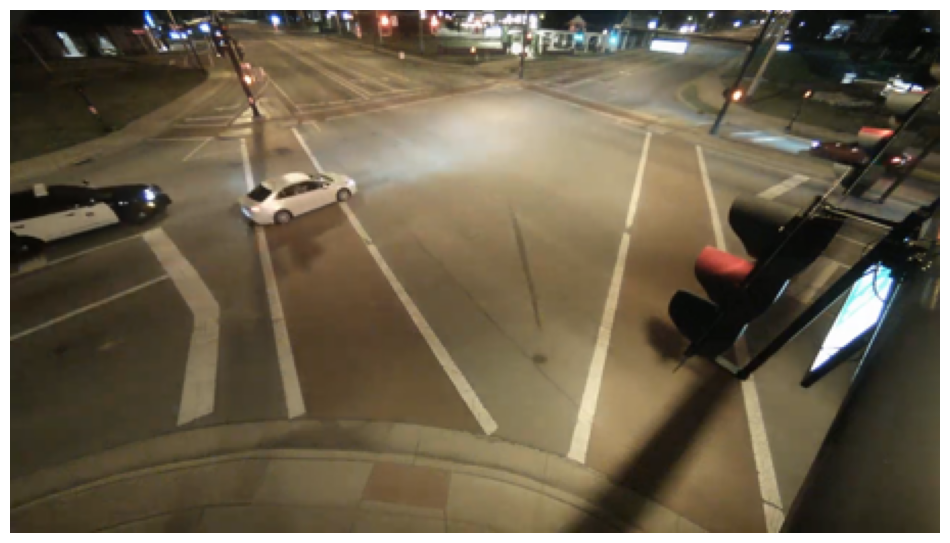

Imaged displayed in 2.7529183 seconds
Using device: cuda:0


KeyboardInterrupt: 

In [42]:
for i in range(1):
  timer(0)
  image = prt_sc()
  print("Imaged captured in " + timer(1) + " seconds")
  aspect_ratio = image.width / image.height
  image = image.resize((int(256 * aspect_ratio), 256))
  print("Imaged resized in " + timer(1) + " seconds")
  sv.plot_image(image)
  print("Imaged displayed in " + timer(1) + " seconds")
  benchmark(image) #<- goes here, then get the average response time of every loop
  print("VLM returned result in " + timer(1) + " seconds")
  #sleep(1)
  #output.clear()

In [30]:
close()
